Data loaded successfully
Shape: (11770077, 39)
   vendor_id     pickup_datetime    dropoff_datetime  passenger_count  \
0          2 2024-11-01 00:46:24 2024-11-01 00:57:17              1.0   
1          2 2024-11-01 00:12:55 2024-11-01 00:22:17              2.0   
2          2 2024-11-01 00:54:45 2024-11-01 00:59:47              1.0   
3          2 2024-11-01 00:19:00 2024-11-01 00:21:28              1.0   
4          2 2024-11-01 00:42:45 2024-11-01 00:56:23              2.0   

   trip_distance  ratecode_id store_and_fwd_flag  PULocationID  DOLocationID  \
0           1.93          1.0                  N           239           263   
1           0.93          1.0                  N           186           107   
2           0.38          1.0                  N            79            79   
3           0.48          1.0                  N           237           236   
4           2.61          1.0                  N            43           116   

   payment_type  ...             

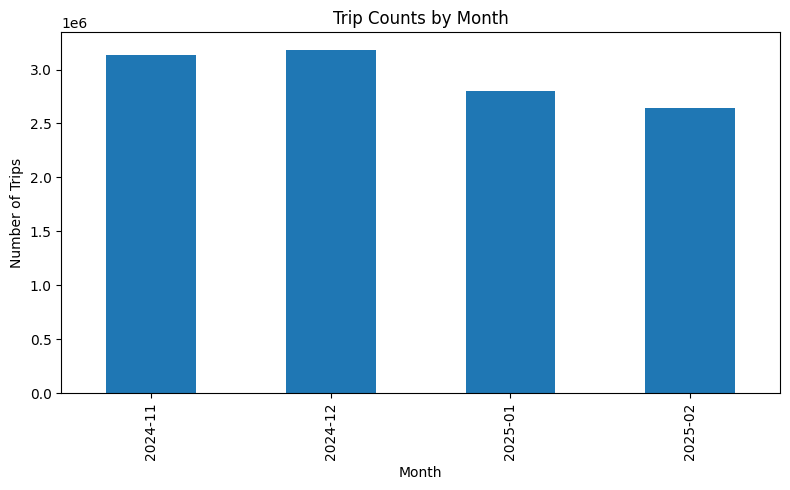

pickup_hour
0     300028
1     197160
2     126779
3      80821
4      53608
5      61900
6     140724
7     298455
8     424023
9     496748
10    553040
11    601799
12    654129
13    680409
14    733147
15    768215
16    779299
17    830130
18    852063
19    737441
20    675759
21    686049
22    596513
23    441838
dtype: int64


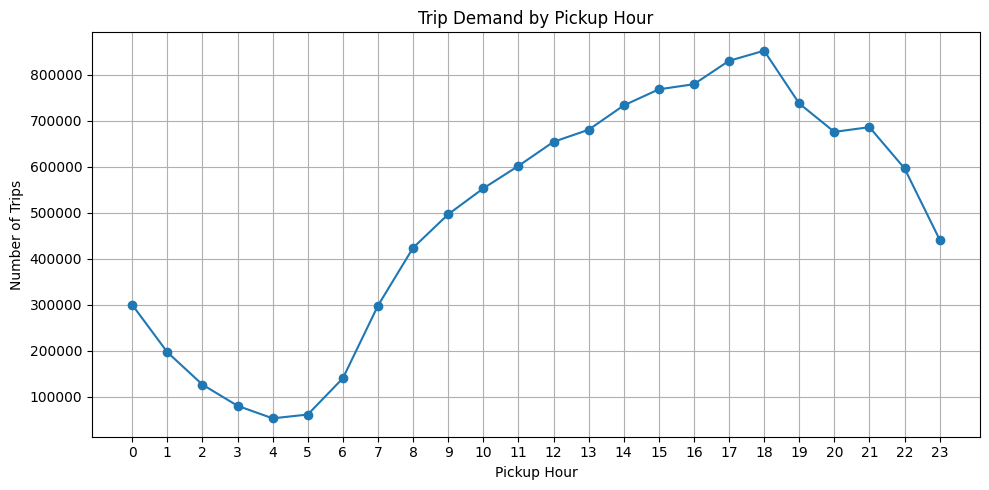

pickup_dayofweek
Mon    1445977
Tue    1661664
Wed    1710760
Thu    1812826
Fri    1893935
Sat    1789531
Sun    1455384
dtype: int64


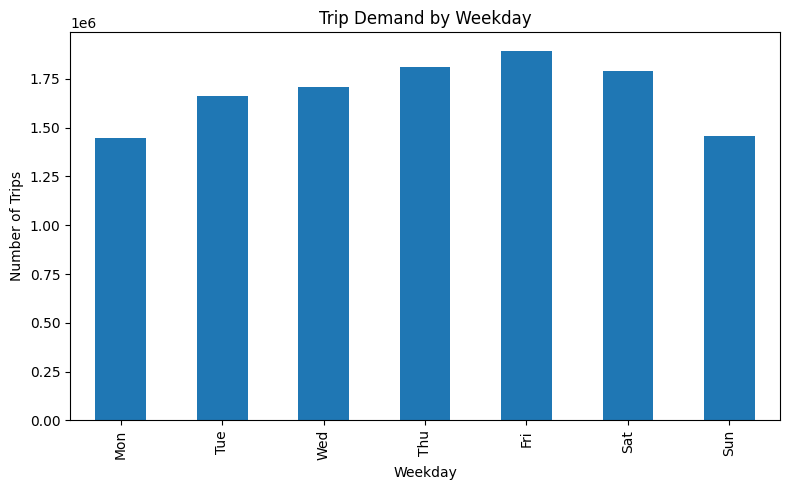

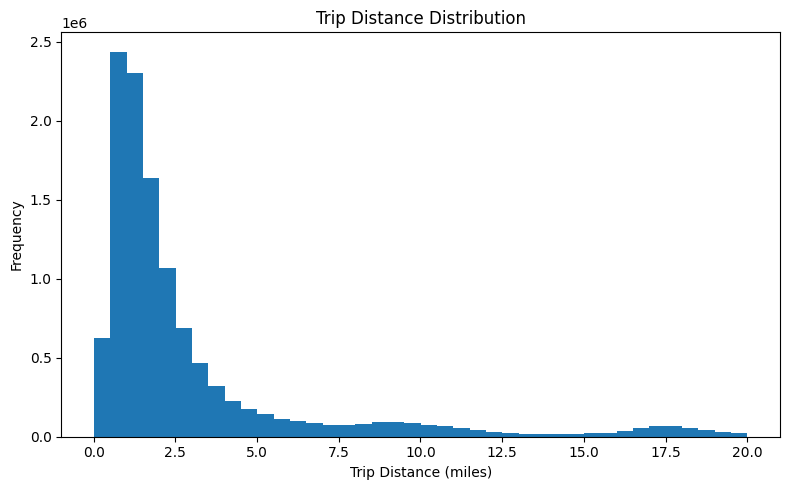

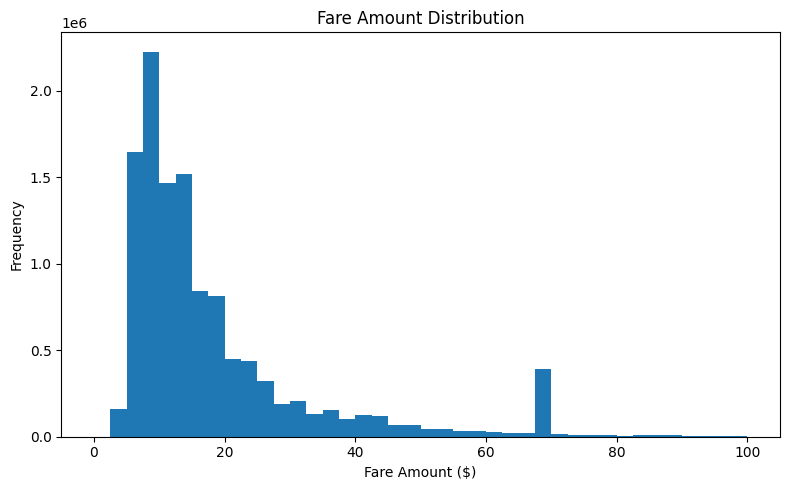

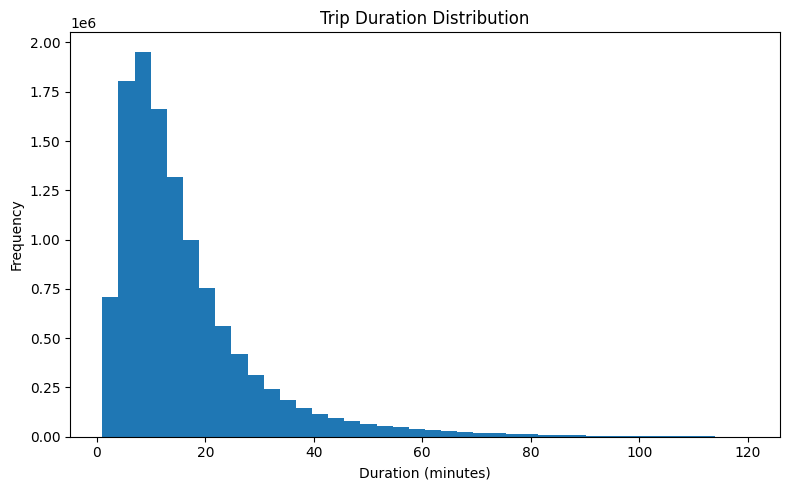

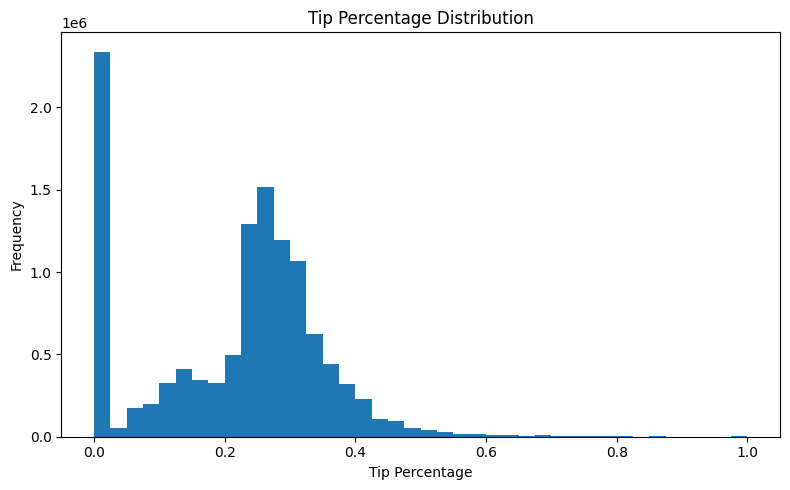

payment_type
1    10036426
2     1542802
3       48942
4      141907
Name: count, dtype: int64


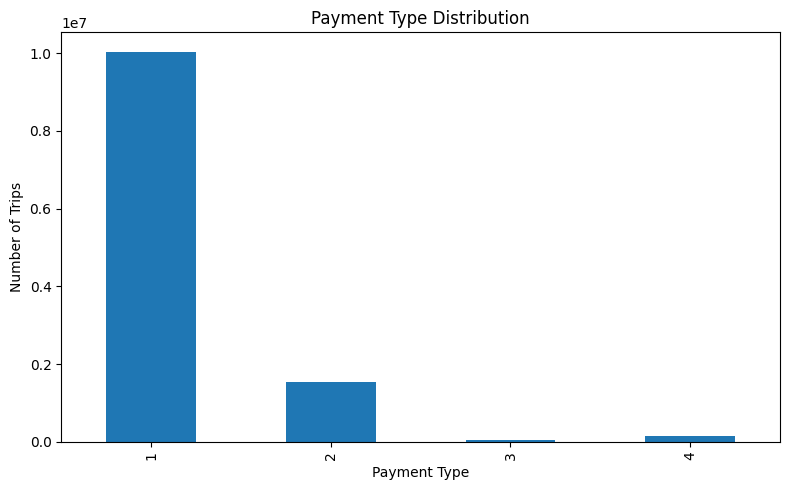

PUBorough
Manhattan        10645921
Queens             999190
Brooklyn           101589
Bronx               23059
Staten Island         243
EWR                    75
Name: count, dtype: int64


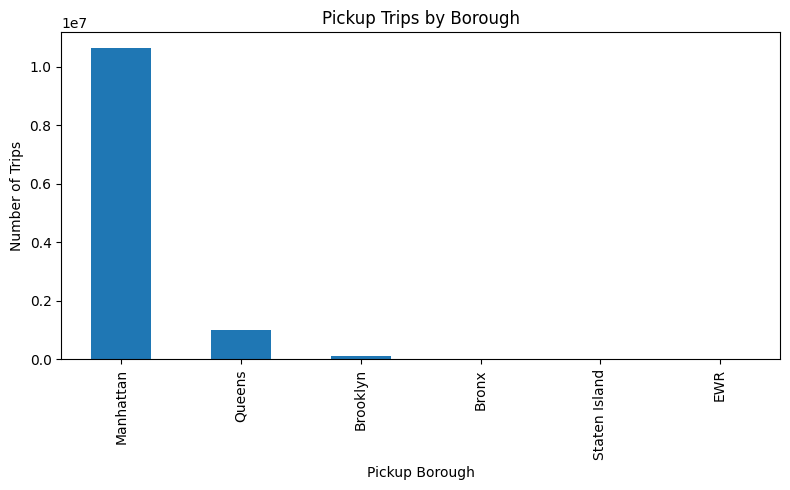

DOBorough
Manhattan        10715785
Queens             504218
Brooklyn           458011
Bronx               60508
EWR                 29054
Staten Island        2501
Name: count, dtype: int64


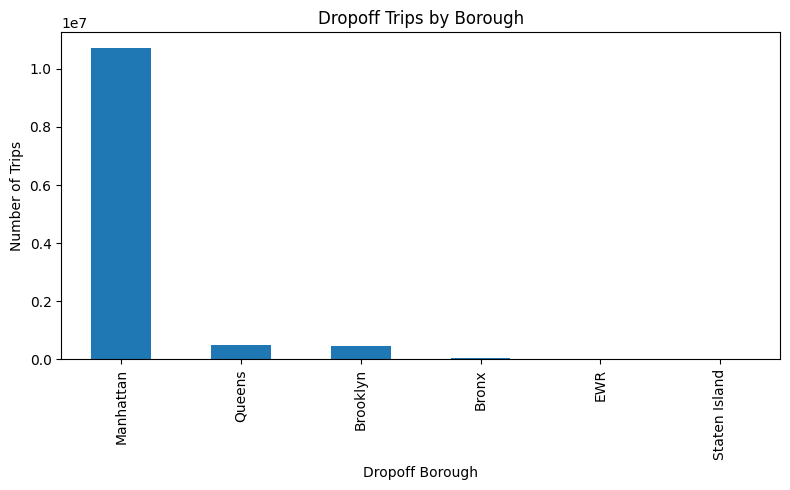

C:\Users\wangp\AppData\Local\Temp\ipykernel_38588\1562959070.py:195: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["PUBorough", "PUZone"])


      PUBorough                        PUZone  trip_count
1005  Manhattan         Upper East Side South      625623
928   Manhattan                Midtown Center      586984
1004  Manhattan         Upper East Side North      559734
1153     Queens                   JFK Airport      520352
954   Manhattan  Penn Station/Madison Sq West      442644
929   Manhattan                  Midtown East      436034
998   Manhattan     Times Sq/Theatre District      426459
909   Manhattan           Lincoln Square East      411036
1163     Queens             LaGuardia Airport      372429
930   Manhattan                 Midtown North      364069
1007  Manhattan         Upper West Side South      343482
937   Manhattan                   Murray Hill      334259
1002  Manhattan                      Union Sq      332049
838   Manhattan                  East Chelsea      319960
819   Manhattan                  Clinton East      300169


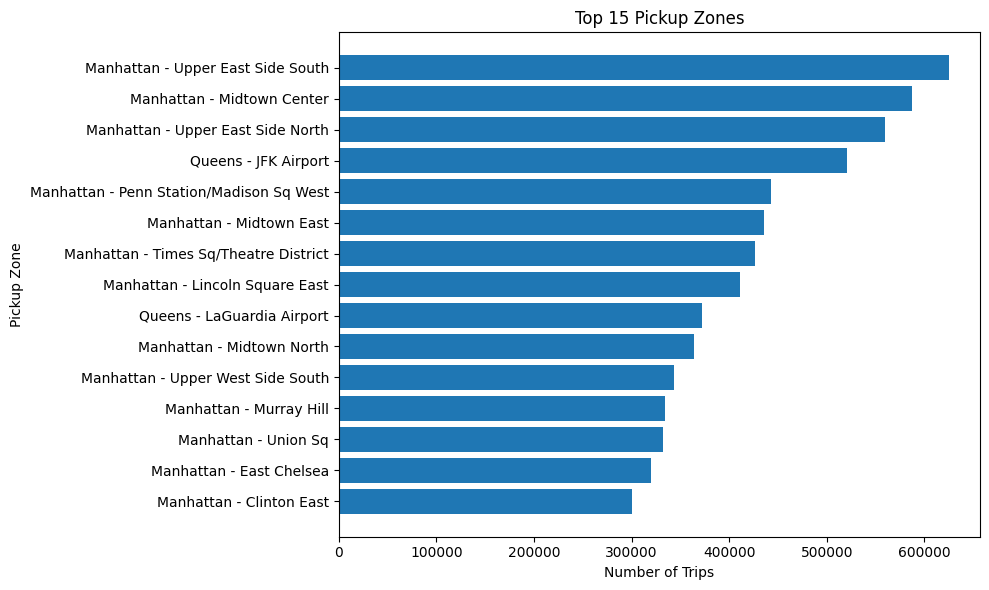

            trip_count  avg_distance   avg_fare  avg_duration  avg_tip_pct
is_holiday                                                                
False         11370576      3.164119  18.560873     16.313204     0.218391
True            399501      3.749526  19.690914     14.859756     0.207494


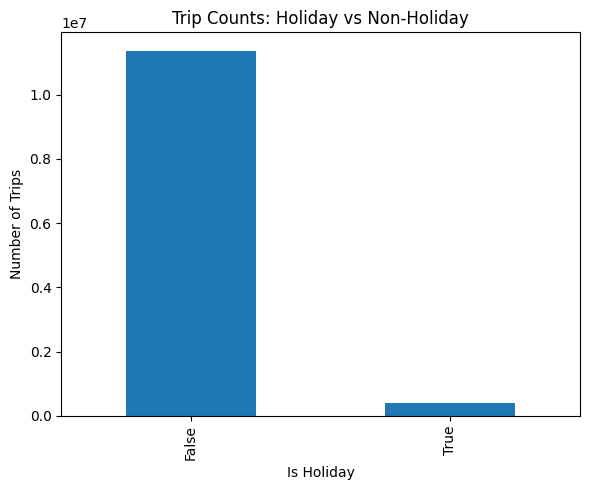

                     trip_count  avg_distance   avg_fare  avg_duration  \
post_congestion_fee                                                      
False                   6637380      3.274983  19.498692     17.494429   
True                    5132697      3.066319  17.436083     14.672568   

                     avg_tip_pct  avg_cbd_fee  
post_congestion_fee                            
False                   0.212076     0.000040  
True                    0.225709     0.556934  


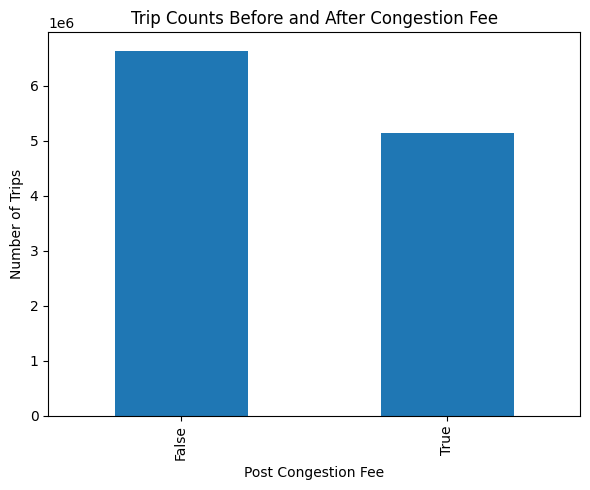

  pickup_date  daily_trips
0  2024-11-01       115760
1  2024-11-02       119147
2  2024-11-03        99737
3  2024-11-04        91289
4  2024-11-05        88154


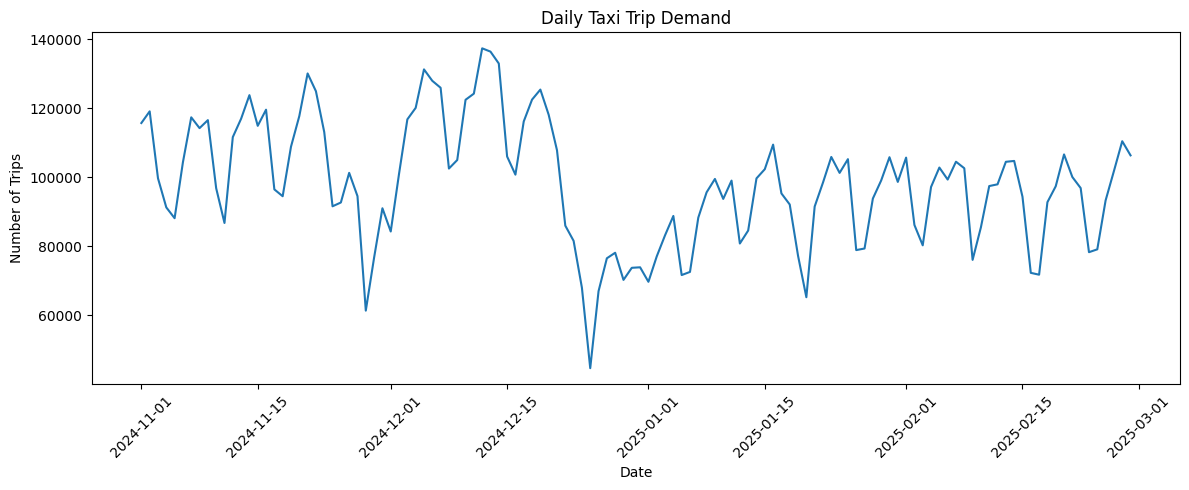

  pickup_date  daily_trips  avg_temperature  avg_precipitation  avg_snow  \
0  2024-11-01       115760        21.438894           0.011299       0.0   
1  2024-11-02       119147        12.711055           0.000000       0.0   
2  2024-11-03        99737         8.827775           0.000000       0.0   
3  2024-11-04        91289        11.378518           0.000000       0.0   
4  2024-11-05        88154        18.231890           0.000000       0.0   

   avg_humidity  avg_wind_speed  
0     43.759701       21.333569  
1     46.064022       14.636565  
2     41.792805       10.290894  
3     65.230137       13.308977  
4     69.614572       15.630216  


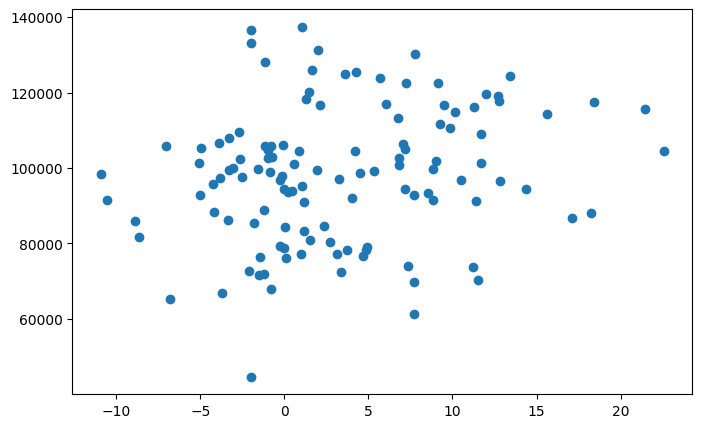

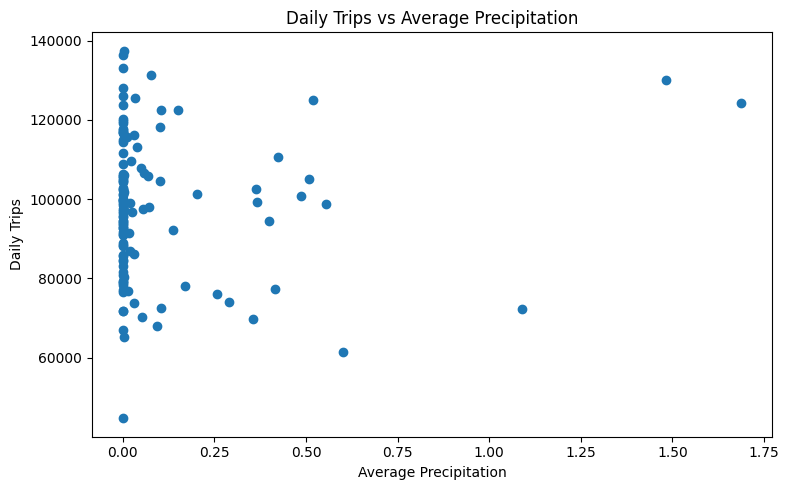

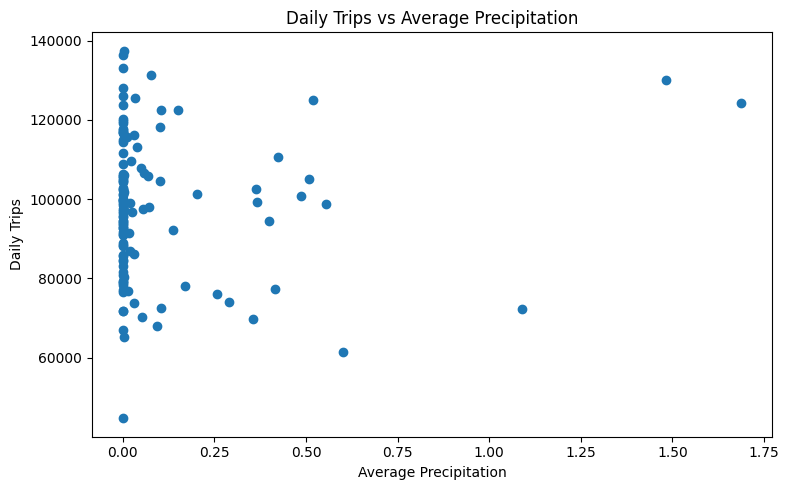

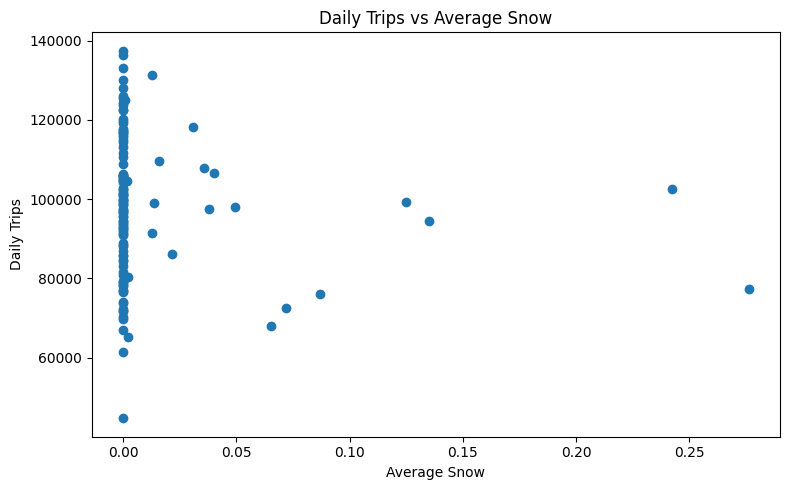

                     number_of_days  avg_daily_trips
precipitation_group                                 
No rain                          70     98178.357143
Light rain                       18     98835.000000
Moderate rain                    15     99723.666667
Heavy rain                       17     95453.352941


C:\Users\wangp\AppData\Local\Temp\ipykernel_38588\1562959070.py:323: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  precip_summary = daily_weather.groupby("precipitation_group").agg(


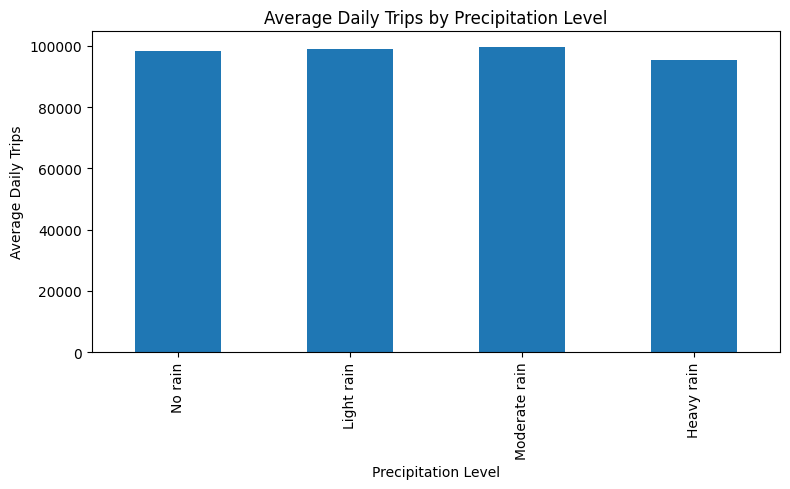

                   daily_trips  avg_temperature  avg_precipitation  avg_snow  \
daily_trips           1.000000         0.207264           0.070704 -0.110939   
avg_temperature       0.207264         1.000000           0.161727 -0.153220   
avg_precipitation     0.070704         0.161727           1.000000  0.193333   
avg_snow             -0.110939        -0.153220           0.193333  1.000000   
avg_humidity         -0.195497         0.070785           0.596378  0.249036   
avg_wind_speed        0.082933         0.230679           0.039631 -0.146744   

                   avg_humidity  avg_wind_speed  
daily_trips           -0.195497        0.082933  
avg_temperature        0.070785        0.230679  
avg_precipitation      0.596378        0.039631  
avg_snow               0.249036       -0.146744  
avg_humidity           1.000000       -0.259391  
avg_wind_speed        -0.259391        1.000000  


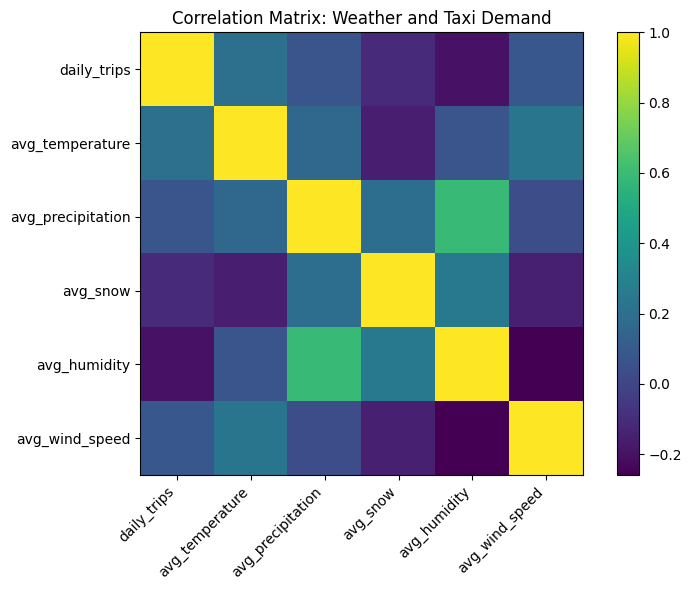

EDA outputs saved in eda_outputs folder.


In [2]:
# ============================================
# NYC Taxi EDA
# Based on clean_trips.parquet
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import os

# Create output folder for EDA plots
os.makedirs("eda_outputs", exist_ok=True)

# Load cleaned data
df = pd.read_parquet("data/processed/clean_trips.parquet")

print("Data loaded successfully")
print("Shape:", df.shape)
print(df.head())

# Basic dataset information
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

# Summary statistics for key numeric variables
key_vars = [
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "duration_minutes",
    "avg_speed_mph",
    "tip_pct",
    "temperature",
    "precipitation",
    "snow",
    "humidity",
    "wind_speed"
]

summary_stats = df[key_vars].describe().T
print(summary_stats)

summary_stats.to_csv("eda_outputs/summary_statistics.csv")

monthly_counts = df["source_month"].value_counts().sort_index()

print(monthly_counts)

plt.figure(figsize=(8, 5))
monthly_counts.plot(kind="bar")
plt.title("Trip Counts by Month")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.savefig("eda_outputs/monthly_trip_counts.png")
plt.show()

hourly_counts = df.groupby("pickup_hour").size()

print(hourly_counts)

plt.figure(figsize=(10, 5))
hourly_counts.plot(kind="line", marker="o")
plt.title("Trip Demand by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Number of Trips")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.savefig("eda_outputs/trip_demand_by_hour.png")
plt.show()

weekday_counts = df.groupby("pickup_dayofweek").size()

weekday_names = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun"
}

weekday_counts.index = weekday_counts.index.map(weekday_names)

print(weekday_counts)

plt.figure(figsize=(8, 5))
weekday_counts.plot(kind="bar")
plt.title("Trip Demand by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.savefig("eda_outputs/trip_demand_by_weekday.png")
plt.show()

# Cap distance at 20 miles for clearer visualization
distance_data = df[df["trip_distance"] <= 20]["trip_distance"]

plt.figure(figsize=(8, 5))
plt.hist(distance_data, bins=40)
plt.title("Trip Distance Distribution")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("eda_outputs/trip_distance_distribution.png")
plt.show()

# Cap fare at $100 for clearer visualization
fare_data = df[df["fare_amount"] <= 100]["fare_amount"]

plt.figure(figsize=(8, 5))
plt.hist(fare_data, bins=40)
plt.title("Fare Amount Distribution")
plt.xlabel("Fare Amount ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("eda_outputs/fare_amount_distribution.png")
plt.show()

# Cap duration at 120 minutes for clearer visualization
duration_data = df[df["duration_minutes"] <= 120]["duration_minutes"]

plt.figure(figsize=(8, 5))
plt.hist(duration_data, bins=40)
plt.title("Trip Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("eda_outputs/trip_duration_distribution.png")
plt.show()

# Keep tip percentage between 0 and 1 for clearer visualization
tip_data = df[(df["tip_pct"] >= 0) & (df["tip_pct"] <= 1)]["tip_pct"]

plt.figure(figsize=(8, 5))
plt.hist(tip_data, bins=40)
plt.title("Tip Percentage Distribution")
plt.xlabel("Tip Percentage")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("eda_outputs/tip_percentage_distribution.png")
plt.show()

payment_counts = df["payment_type"].value_counts().sort_index()

print(payment_counts)

plt.figure(figsize=(8, 5))
payment_counts.plot(kind="bar")
plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.savefig("eda_outputs/payment_type_distribution.png")
plt.show()

pickup_borough_counts = df["PUBorough"].value_counts()

print(pickup_borough_counts)

plt.figure(figsize=(8, 5))
pickup_borough_counts.plot(kind="bar")
plt.title("Pickup Trips by Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.savefig("eda_outputs/pickup_borough_distribution.png")
plt.show()

dropoff_borough_counts = df["DOBorough"].value_counts()

print(dropoff_borough_counts)

plt.figure(figsize=(8, 5))
dropoff_borough_counts.plot(kind="bar")
plt.title("Dropoff Trips by Borough")
plt.xlabel("Dropoff Borough")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.savefig("eda_outputs/dropoff_borough_distribution.png")
plt.show()

top_pickup_zones = (
    df.groupby(["PUBorough", "PUZone"])
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
    .head(15)
)

print(top_pickup_zones)

plt.figure(figsize=(10, 6))
labels = top_pickup_zones["PUBorough"].astype(str) + " - " + top_pickup_zones["PUZone"].astype(str)

plt.barh(labels[::-1], top_pickup_zones["trip_count"][::-1])
plt.title("Top 15 Pickup Zones")
plt.xlabel("Number of Trips")
plt.ylabel("Pickup Zone")
plt.tight_layout()
plt.savefig("eda_outputs/top_pickup_zones.png")
plt.show()

holiday_summary = df.groupby("is_holiday").agg(
    trip_count=("pickup_datetime", "count"),
    avg_distance=("trip_distance", "mean"),
    avg_fare=("fare_amount", "mean"),
    avg_duration=("duration_minutes", "mean"),
    avg_tip_pct=("tip_pct", "mean")
)

print(holiday_summary)

holiday_summary.to_csv("eda_outputs/holiday_summary.csv")

plt.figure(figsize=(6, 5))
holiday_summary["trip_count"].plot(kind="bar")
plt.title("Trip Counts: Holiday vs Non-Holiday")
plt.xlabel("Is Holiday")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.savefig("eda_outputs/holiday_trip_counts.png")
plt.show()

policy_summary = df.groupby("post_congestion_fee").agg(
    trip_count=("pickup_datetime", "count"),
    avg_distance=("trip_distance", "mean"),
    avg_fare=("fare_amount", "mean"),
    avg_duration=("duration_minutes", "mean"),
    avg_tip_pct=("tip_pct", "mean"),
    avg_cbd_fee=("cbd_congestion_fee", "mean")
)

print(policy_summary)

policy_summary.to_csv("eda_outputs/congestion_fee_summary.csv")

plt.figure(figsize=(6, 5))
policy_summary["trip_count"].plot(kind="bar")
plt.title("Trip Counts Before and After Congestion Fee")
plt.xlabel("Post Congestion Fee")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.savefig("eda_outputs/pre_post_congestion_fee_trip_counts.png")
plt.show()

df["pickup_date"] = pd.to_datetime(df["pickup_date"])

daily_trips = df.groupby("pickup_date").size().reset_index(name="daily_trips")

print(daily_trips.head())

plt.figure(figsize=(12, 5))
plt.plot(daily_trips["pickup_date"], daily_trips["daily_trips"])
plt.title("Daily Taxi Trip Demand")
plt.xlabel("Date")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("eda_outputs/daily_trip_demand.png")
plt.show()

daily_weather = df.groupby("pickup_date").agg(
    daily_trips=("pickup_datetime", "count"),
    avg_temperature=("temperature", "mean"),
    avg_precipitation=("precipitation", "mean"),
    avg_snow=("snow", "mean"),
    avg_humidity=("humidity", "mean"),
    avg_wind_speed=("wind_speed", "mean")
).reset_index()

print(daily_weather.head())

daily_weather.to_csv("eda_outputs/daily_weather_demand.csv", index=False)

plt.figure(figsize=(8, 5))
plt.scatter(daily_weather["avg_temperature"], daily_weather["daily_trips"])
plt.figure(figsize=(8, 5))
plt.scatter(daily_weather["avg_precipitation"], daily_weather["daily_trips"])
plt.title("Daily Trips vs Average Precipitation")
plt.xlabel("Average Precipitation")
plt.ylabel("Daily Trips")
plt.tight_layout()
plt.savefig("eda_outputs/daily_trips_vs_precipitation.png")
plt.show()


plt.figure(figsize=(8, 5))
plt.scatter(daily_weather["avg_precipitation"], daily_weather["daily_trips"])
plt.title("Daily Trips vs Average Precipitation")
plt.xlabel("Average Precipitation")
plt.ylabel("Daily Trips")
plt.tight_layout()
plt.savefig("eda_outputs/daily_trips_vs_precipitation.png")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(daily_weather["avg_snow"], daily_weather["daily_trips"])
plt.title("Daily Trips vs Average Snow")
plt.xlabel("Average Snow")
plt.ylabel("Daily Trips")
plt.tight_layout()
plt.savefig("eda_outputs/daily_trips_vs_snow.png")
plt.show()

daily_weather["precipitation_group"] = pd.cut(
    daily_weather["avg_precipitation"],
    bins=[-0.001, 0, 0.05, 0.2, daily_weather["avg_precipitation"].max() + 1],
    labels=["No rain", "Light rain", "Moderate rain", "Heavy rain"]
)

precip_summary = daily_weather.groupby("precipitation_group").agg(
    number_of_days=("pickup_date", "count"),
    avg_daily_trips=("daily_trips", "mean")
)

print(precip_summary)

precip_summary.to_csv("eda_outputs/precipitation_summary.csv")

plt.figure(figsize=(8, 5))
precip_summary["avg_daily_trips"].plot(kind="bar")
plt.title("Average Daily Trips by Precipitation Level")
plt.xlabel("Precipitation Level")
plt.ylabel("Average Daily Trips")
plt.tight_layout()
plt.savefig("eda_outputs/avg_daily_trips_by_precipitation.png")
plt.show()

corr_vars = [
    "daily_trips",
    "avg_temperature",
    "avg_precipitation",
    "avg_snow",
    "avg_humidity",
    "avg_wind_speed"
]

corr_matrix = daily_weather[corr_vars].corr()

print(corr_matrix)

corr_matrix.to_csv("eda_outputs/weather_demand_correlation.csv")

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_vars)), corr_vars, rotation=45, ha="right")
plt.yticks(range(len(corr_vars)), corr_vars)
plt.title("Correlation Matrix: Weather and Taxi Demand")
plt.tight_layout()
plt.savefig("eda_outputs/weather_demand_correlation_matrix.png")
plt.show()

monthly_counts.to_csv("eda_outputs/monthly_trip_counts.csv")
hourly_counts.to_csv("eda_outputs/hourly_trip_counts.csv")
weekday_counts.to_csv("eda_outputs/weekday_trip_counts.csv")
pickup_borough_counts.to_csv("eda_outputs/pickup_borough_counts.csv")
dropoff_borough_counts.to_csv("eda_outputs/dropoff_borough_counts.csv")
top_pickup_zones.to_csv("eda_outputs/top_pickup_zones.csv", index=False)

print("EDA outputs saved in eda_outputs folder.")


